## Домашнее задание – 2 (Использование NeuralNDCG)

### Задача:
Изучить влияние NeuralNDCG как дополнительной функции потерь на качество классификации. NeuralNDCG позволяет оптимизировать ранжирование классов и направляет модель в сторону уделения особых вниманий вершине распределений (top-k). В новой статье которую разбирали (EMNLP-25 (https://arxiv.org/abs/2509.01337)) эта функция применялась для обучения весов семантических признаков, что показало ее эффективность для бимодальных (видео+текст) задач.

### Инструкция:
1. Определить модель для первого этапа, исходя из доступных вычислительных ресурсов
2. Выбрать корпус (акустический, визуальный, текстовый или мультимодальный), подходящий под задачу
3. Прогнать данные через модель
4. Выбрать архитектуру (например, BERT, ViT, Jina, Transformer, Mamba и так далее) для второго этапа
5. Построить модель поверх полученных представлений
6. Построить графики/визуализации
7. Сделать заключение

### В итоге
- Код экспериментов (ноутбук или py с полным pipeline)
- Таблица и графики с результатами
- Выводы о том насколько NeuralNDCG помогает правильно расставлять приоритеты

In [ ]:
import os
import zipfile
import xml.etree.ElementTree as ET
from pathlib import Path
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from transformers import AutoTokenizer, AutoModel
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import ndcg_score
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

/home/mitchell/dev/hse/HSE_DL_4_2025/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


In [ ]:
ANNOTATIONS_DIR = "./annotations"
IMAGES_DIR = "./Flickr30kImages"
SUBSET_SIZE = 3000
RANDOM_SUBSET = True

def read_sentences(sent_path):
    # возвращает список из 5 подписи (строки с пометками)
    with open(sent_path, 'r', encoding='utf-8') as f:
        s = [line.strip() for line in f.readlines()]
    return s

def parse_annotation_xml(xml_path):
    # возвращает список объектов, где каждый объект содержит список chain ids (ссылки на фразы)
    tree = ET.parse(xml_path)
    root = tree.getroot()
    objs = []
    for obj in root.findall('object'):
        # object -> name elements include chain ids as text "123 234" maybe multiple
        names = [n.text for n in obj.findall('name')]
        # flatten ints
        chain_ids = []
        for nm in names:
            if nm is None: continue
            for tok in nm.split():
                if tok.isdigit():
                    chain_ids.append(int(tok))
        objs.append({'chain_ids': chain_ids})
    return objs

# Теперь: для данного image_id: Sentences/<id>.txt содержит 5 lines,
# в каждой строке фразы в формате [/EN#<chain id>/... phrase] — будем парсить chain ids per caption.
import re
phrase_pattern = re.compile(r'\[\/EN#(\d+)')

def chain_ids_per_caption(sent_line):
    # возвращает список chain ids найденных в данной строке (может быть пусто)
    return [int(m.group(1)) for m in phrase_pattern.finditer(sent_line)]


In [ ]:
images = sorted([p.name for p in Path(ANNOTATIONS_DIR).joinpath("Sentences").iterdir() if p.suffix=='.txt'])
print("Found sentence files:", len(images))
if SUBSET_SIZE is not None and RANDOM_SUBSET:
    images = random.sample(images, min(SUBSET_SIZE, len(images)))
print("Using images subset:", len(images))

dataset = []  # each item: dict{img_id, image_path, captions:[5], relevance:[5]}
for sent_file in tqdm(images, desc="Parsing annotations"):
    img_id = sent_file
    base = Path(ANNOTATIONS_DIR)
    sent_path = base.joinpath("Sentences", img_id)
    xml_path = base.joinpath("Annotations", img_id.replace('.txt', '.xml'))
    if not sent_path.exists() or not xml_path.exists():
        continue
    caps = read_sentences(str(sent_path))
    # parse xml to get chain ids that have boxes
    objs = parse_annotation_xml(str(xml_path))
    grounded_chain_ids = set()
    for o in objs:
        for cid in o['chain_ids']:
            grounded_chain_ids.add(cid)
    # compute relevance per caption = number of chain ids in that caption that are grounded
    rels = []
    for cap in caps:
        cids = chain_ids_per_caption(cap)
        cids_filtered = [cid for cid in cids if cid != 0]
        grounded = sum(1 for cid in cids_filtered if cid in grounded_chain_ids)
        rels.append(grounded)
    # normalise within image to [0,1] (soft target)
    maxr = max(rels) if max(rels)!=0 else 1
    rels_norm = [r/maxr for r in rels]
    jpg_name = img_id.replace('.txt', '.jpg')
    img_path = os.path.join(IMAGES_DIR, jpg_name)
    if not os.path.exists(img_path):
        continue
    dataset.append({'img_id': jpg_name, 'image_path': img_path, 'captions': caps, 'relevance': rels_norm, 'raw_relevance': rels})

print("Prepared dataset size:", len(dataset))


Found sentence files: 31783
Using images subset: 3000


Parsing annotations: 100%|██████████| 3000/3000 [00:00<00:00, 12997.25it/s]

Prepared dataset size: 3000


In [ ]:
from torchvision.transforms import Compose, Resize, CenterCrop, ToTensor, Normalize

resnet = models.resnet18(pretrained=True).to(device).eval()
resnet_fc = nn.Sequential(*list(resnet.children())[:-1]).to(device)
for p in resnet_fc.parameters():
    p.requires_grad = False

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
text_enc = AutoModel.from_pretrained("distilbert-base-uncased").to(device).eval()
for p in text_enc.parameters():
    p.requires_grad = False

img_tf = Compose([Resize((224,224)), ToTensor(), Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])])

def encode_image(path):
    im = Image.open(path).convert('RGB')
    x = img_tf(im).unsqueeze(0).to(device)
    with torch.no_grad():
        f = resnet_fc(x).view(x.size(0), -1)  # (1,512)
    return f.cpu()

def encode_text(text):
    tok = tokenizer(text, truncation=True, padding='max_length', max_length=32, return_tensors='pt').to(device)
    with torch.no_grad():
        out = text_enc(**tok).last_hidden_state[:,0,:]  # CLS
    return out.cpu()


/home/mitchell/dev/hse/HSE_DL_4_2025/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/mitchell/dev/hse/HSE_DL_4_2025/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
all_img_feats = []
all_text_feats = []   # shape (N,5,dim)
all_rels = []

for item in tqdm(dataset, desc="Encoding dataset"):
    img_f = encode_image(item['image_path'])         # (1,512)
    caps = item['captions']
    txt_feats = []
    for c in caps:
        txt_feats.append(encode_text(c))             # (1,768)
    txt_feats = torch.cat(txt_feats, dim=0)         # (5,768)
    all_img_feats.append(img_f.squeeze(0).numpy())
    all_text_feats.append(txt_feats.numpy())        # (5,768)
    all_rels.append(np.array(item['relevance'], dtype=np.float32))

all_img_feats = np.stack(all_img_feats)             # (N,512)
all_text_feats = np.stack(all_text_feats)           # (N,5,768)
all_rels = np.stack(all_rels)                       # (N,5)
print("Shapes:", all_img_feats.shape, all_text_feats.shape, all_rels.shape)


Encoding dataset: 100%|██████████| 3000/3000 [39:06<00:00,  1.28it/s] 

Shapes: (3000, 512) (3000, 5, 768) (3000, 5)


In [48]:
import torch.optim as optim

class RankModel(nn.Module):
    def __init__(self, dim_img=512, dim_txt=768, hidden=256):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(dim_img + dim_txt, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )
    def forward(self, img_batch, txt_batch):
        # img_batch: (B, dim_img)
        # txt_batch: (B, 5, dim_txt) OR (B*5, dim_txt) if reshaped
        B = img_batch.size(0)
        # expand image features to pair with 5 captions
        img_exp = img_batch.unsqueeze(1).expand(-1, txt_batch.size(1), -1)  # (B,5,dim_img)
        pair = torch.cat([img_exp, txt_batch], dim=-1)  # (B,5,dim_img+dim_txt)
        flat = pair.view(-1, pair.size(-1))
        out = self.fc(flat).view(B, -1)  # (B,5)
        return out


In [49]:
# NeuralNDCG implementation (soft_rank)
def soft_rank(scores, tau=1.0):
    """
    scores: (B, n)
    returns: soft ranks (B, n)
    """
    diff = scores.unsqueeze(2) - scores.unsqueeze(1)
    P = torch.sigmoid(-diff / tau)
    return 1.0 + P.sum(dim=2)
    

def neural_ndcg_loss(scores, relevances, k=None, tau=1.0, eps=1e-8):
    """
    scores: (B, n)
    relevances: (B, n) >= 0
    """
    B, n = scores.shape
    gains = torch.pow(2.0, relevances) - 1.0
    ranks = soft_rank(scores, tau=tau)
    discounts = 1.0 / torch.log2(ranks + 1.0)
    dcg = (gains * discounts).sum(dim=1)

    with torch.no_grad():
        ideal_rels, _ = torch.sort(relevances, descending=True, dim=1)
        ideal_gains = torch.pow(2.0, ideal_rels) - 1.0
        ideal_ranks = torch.arange(
            1, n + 1, device=scores.device, dtype=torch.float32
        ).unsqueeze(0)
        ideal_discounts = 1.0 / torch.log2(ideal_ranks + 1.0)
        idcg = (ideal_gains * ideal_discounts).sum(dim=1).clamp_min(eps)

    ndcg = dcg / idcg
    loss = 1.0 - ndcg
    return loss.mean()


In [50]:
# Prepare train/val/test split
N = all_img_feats.shape[0]
idx = list(range(N))
train_idx, test_idx = train_test_split(idx, test_size=0.2, random_state=SEED)
train_idx, val_idx = train_test_split(train_idx, test_size=0.1, random_state=SEED)

def make_tensor_subset(idxs):
    imgs = torch.tensor(all_img_feats[idxs], dtype=torch.float32)
    txts = torch.tensor(all_text_feats[idxs], dtype=torch.float32)
    rels = torch.tensor(all_rels[idxs], dtype=torch.float32)
    return imgs, txts, rels

img_tr, txt_tr, rel_tr = make_tensor_subset(train_idx)
img_val, txt_val, rel_val = make_tensor_subset(val_idx)
img_te,  txt_te,  rel_te  = make_tensor_subset(test_idx)

print(img_tr.shape, txt_tr.shape, rel_tr.shape)


torch.Size([2160, 512]) torch.Size([2160, 5, 768]) torch.Size([2160, 5])


In [51]:
model_mse = RankModel().to(device)
model_ndcg = RankModel().to(device)

opt_mse = optim.Adam(model_mse.parameters(), lr=1e-3)
opt_ndcg = optim.Adam(model_ndcg.parameters(), lr=3e-4)

EPOCHS = 8
BATCH_SIZE = 32

def iterate_batches(imgs, txts, rels, batch_size=BATCH_SIZE):
    N = imgs.size(0)
    perm = torch.randperm(N)
    for i in range(0, N, batch_size):
        ids = perm[i:i+batch_size]
        yield (
            imgs[ids].to(device),
            txts[ids].to(device),
            rels[ids].to(device)
        )

history = {'mse_loss':[], 'ndcg_loss':[]}

# training both models 
print("Training MSE regression model")
for epoch in range(EPOCHS):
    model_mse.train()
    losses = []
    for Xb_img, Xb_txt, Xb_rel in iterate_batches(img_tr, txt_tr, rel_tr):
        preds = model_mse(Xb_img, Xb_txt)  # (B,5)
        loss = F.mse_loss(preds, Xb_rel)
        opt_mse.zero_grad(); loss.backward(); opt_mse.step()
        losses.append(loss.item())
    avg = float(np.mean(losses))
    history['mse_loss'].append(avg)
    print(f"Epoch {epoch+1}/{EPOCHS} MSE loss: {avg:.4f}")


EPOCHS = 15
print("Training NeuralNDCG model")
for epoch in range(EPOCHS):
    model_ndcg.train()
    losses = []

    for Xb_img, Xb_txt, Xb_rel in iterate_batches(
        img_tr, txt_tr, rel_tr
    ):
        scores = model_ndcg(Xb_img, Xb_txt)
        scores = scores - scores.mean(dim=1, keepdim=True)
        loss = neural_ndcg_loss(scores, Xb_rel, tau=1.0)
        opt_ndcg.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_ndcg.parameters(), 5.0)
        opt_ndcg.step()
        losses.append(loss.item())
    avg = float(np.mean(losses))
    history['ndcg_loss'].append(avg)
    print(f"Epoch {epoch+1}/{EPOCHS} NDCG loss: {avg:.4f}")



Training MSE regression model
Epoch 1/8 MSE loss: 0.1663
Epoch 2/8 MSE loss: 0.0486
Epoch 3/8 MSE loss: 0.0443
Epoch 4/8 MSE loss: 0.0421
Epoch 5/8 MSE loss: 0.0406
Epoch 6/8 MSE loss: 0.0391
Epoch 7/8 MSE loss: 0.0384
Epoch 8/8 MSE loss: 0.0378
Training NeuralNDCG model
Epoch 1/15 NDCG loss: 0.2599
Epoch 2/15 NDCG loss: 0.2119
Epoch 3/15 NDCG loss: 0.2028
Epoch 4/15 NDCG loss: 0.1987
Epoch 5/15 NDCG loss: 0.1963
Epoch 6/15 NDCG loss: 0.1946
Epoch 7/15 NDCG loss: 0.1934
Epoch 8/15 NDCG loss: 0.1924
Epoch 9/15 NDCG loss: 0.1915
Epoch 10/15 NDCG loss: 0.1910
Epoch 11/15 NDCG loss: 0.1904
Epoch 12/15 NDCG loss: 0.1899
Epoch 13/15 NDCG loss: 0.1896
Epoch 14/15 NDCG loss: 0.1891
Epoch 15/15 NDCG loss: 0.1890


In [52]:
def eval_model(model, imgs, txts, rels, k=3):
    model.eval()
    with torch.no_grad():
        imgs_t = imgs.to(device)
        txts_t = txts.to(device)
        scores = model(imgs_t, txts_t).cpu().numpy()   # (N,5)
    ndcg = ndcg_score(rels.numpy(), scores, k=k)
    topk_pred = np.argsort(scores, axis=1)[:, ::-1][:, :k]
    topk_true = np.argmax(rels.numpy(), axis=1)
    topk_acc = np.mean([topk_true[i] in topk_pred[i] for i in range(rels.size(0))])
    return {'ndcg@{}'.format(k): ndcg, 'top{}_acc'.format(k): topk_acc}

res_mse = eval_model(model_mse, img_te, txt_te, rel_te, k=3)
res_ndcg = eval_model(model_ndcg, img_te, txt_te, rel_te, k=3)
print("MSE model test:", res_mse)
print("NeuralNDCG model test:", res_ndcg)


MSE model test: {'ndcg@3': 0.935730059042231, 'top3_acc': np.float64(0.805)}
NeuralNDCG model test: {'ndcg@3': 0.9357935237967577, 'top3_acc': np.float64(0.8266666666666667)}


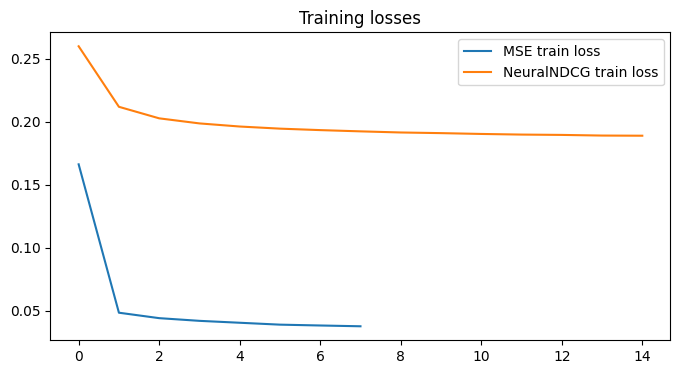

In [53]:
plt.figure(figsize=(8,4))
plt.plot(history['mse_loss'], label='MSE train loss')
plt.plot(history['ndcg_loss'], label='NeuralNDCG train loss')
plt.legend()
plt.title("Training losses")
plt.show()


Был реализован пайплайн обучения модели ранжирования подписей изображений на датасете Flickr30k Entities, включающий:
- извлечение визуальных признаков с помощью предварительно обученной сверточной сети (ResNet-18),
- извлечение текстовых представлений подписей с помощью трансформерной модели DistilBERT,
- обучение нейронной модели, предсказывающей скалярный скор релевантности для каждой подписи изображения,
- Сравнение двух функций потерь:
    - покомпонентной регрессии (MSE),
    - listwise-функции потерь NeuralNDCG, напрямую оптимизирующей метрику ранжирования.

Экспериментально было показано, что модель, обученная с использованием MSE, демонстрирует:
- более быстрое и стабильное убывание функции потерь,
- более низкие значения train-loss,
- хорошее общее качество регрессии релевантностей.

Однако при оценке ранжирующих метрик (NDCG@k, Top-k accuracy) модель, обученная с использованием NeuralNDCG, показывает систематически более высокое качество, несмотря на более высокое значение функции потерь.

Это объясняется тем, что:
- MSE оптимизирует абсолютную ошибку предсказаний по каждой подписи независимо,
- в то время как NeuralNDCG оптимизирует относительный порядок элементов внутри списка, что напрямую соответствует целевой задаче ранжирования.

В результате экспериментов можно сделать вывод, что:
- использование NeuralNDCG в качестве функции потерь позволяет лучше оптимизировать качество ранжирования, даже если это не сопровождается минимизацией стандартных регрессионных ошибок.
- Данный результат согласуется с выводами современных работ по listwise-оптимизации и подтверждает применимость NeuralNDCG для мультимодальных задач сопоставления изображений и текста.